In [1]:
import pandas as pd
import yaml
import sys
import lightgbm as lgb
import joblib
import numpy as np
import shap
import optuna
import duckdb
import warnings
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score, average_precision_score, accuracy_score,  f1_score
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

In [2]:
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [3]:
def test_model(model, X_t, y_t, name="Model", pos_label=1):
    prob_indices = list(model.classes_)
    pos_idx = prob_indices.index(pos_label)
    pred_prob = model.predict_proba(X_t)[:, pos_idx]
    
    pred_acc = model.predict(X_t)
    
    metrics = {
        "ROC-AUC": roc_auc_score(y_t, pred_prob),
        "PR-AUC": average_precision_score(y_t, pred_prob, pos_label=pos_label),
        "Log loss": log_loss(y_t, model.predict_proba(X_t)),
        "Brier Score": brier_score_loss(y_t, pred_prob, pos_label=pos_label),
        "Accuracy": accuracy_score(y_t, pred_acc),
        "F1-Score": f1_score(y_t, pred_acc, pos_label=pos_label)
        }

    df_report = pd.DataFrame.from_dict(metrics, orient='index', columns=[name])
    return df_report


In [4]:
def get_shap(model, X: pd.DataFrame, plot: bool =False) -> list:
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X, check_additivity=False)
    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

    feature_ranking = pd.DataFrame({
        "feature": X.columns,
        "importance": mean_abs_shap
    }).sort_values(by="importance", ascending=False)

    col_ranking = feature_ranking["feature"].tolist()
    
    if plot == True:
        plt.figure(figsize=(10,6))
        shap.plots.beeswarm(shap_values)
        plt.show()

    return col_ranking


In [5]:
def objective(trial):
    
    params = {
        'objective': 'binary',
        'metric': 'average_precision',
        'boosting_type': 'gbdt',
        'n_jobs': -1,
        'verbose': -1,
        "force_row_wise": True,
        "random_state": 42,

        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 7, 127),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
    }

    dtrain = lgb.Dataset(X_train, label=y_train)

    cv_results = lgb.cv(
            params,
            dtrain,
            num_boost_round=1000,
            nfold=5,
            stratified=True,
            callbacks=[
                lgb.early_stopping(stopping_rounds=30, verbose=False),
            ],
        )

    best_pr_auc = cv_results["valid average_precision-mean"][-1]

    best_iteration = len(cv_results["valid average_precision-mean"])
    model_trial = lgb.train(params, dtrain, num_boost_round=best_iteration)
    y_test_pred = model_trial.predict(X_test)
    test_pr_auc = average_precision_score(y_test, y_test_pred)
    value_comp.append((float(best_pr_auc), float(test_pr_auc)))
    
    test_results = {
        "PR-AUC": test_pr_auc,
        "Log loss": log_loss(y_test, y_test_pred),
        "Brier Score": brier_score_loss(y_test, y_test_pred),
    }
    
    dfresults[f"{trial.number}"] = test_results

    trial_params_complete = trial.params.copy()
    trial_params_complete["n_estimators"] = best_iteration

    dfparams[f"{trial.number}"] = trial_params_complete

    return float(best_pr_auc)

In [6]:
def get_top_models(df, top_n=10):
    df_temp = df.copy()
    
    rank_pr = df_temp.loc["PR-AUC"].rank(ascending=False)
    rank_log = df_temp.loc["Log loss"].rank(ascending=True)
    rank_brier = df_temp.loc["Brier Score"].rank(ascending=True)
    
    total_rank = (rank_pr * 1.5) + rank_log + rank_brier
    
    top_model_names = total_rank.sort_values().index[:top_n]
    
    return df[top_model_names]

In [7]:
path_yaml = Path("../../src/config.yaml")
try:

    with open(path_yaml, "r") as file:
        config = yaml.safe_load(file)

except FileNotFoundError:
    print("Config file not found")
    sys.exit(1)



In [8]:
path_preprocessed = Path("../../data/processed/telco_preprocessed.csv")
df = pd.read_csv(path_preprocessed, index_col="customer_id")

pd.set_option('future.no_silent_downcasting', True)


In [9]:
X = df.drop(columns = ["streaming_tv"])
y = df["streaming_tv"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [10]:
num_features = config["features"]["numerical_features"]
ord_features = [config["features"]["ordinal_categoricals"][0]]
nom_features = config["features"]["nominal_categoricals"]
ord_feat_categ = [config["features"]["ordinal_orders"][0]]
col_imp_ranking = config["features"]["columns_ord_shap"]

nom_features.remove("streaming_tv")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("ord", OrdinalEncoder(categories=ord_feat_categ), ord_features),
         ("nom", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), nom_features), 
    ],
    remainder="drop"
)


preprocessor.set_output(transform="pandas")
pass

In [11]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [12]:
quick_map = {"yes": 1, "no": 0}
y_train = y_train.replace(quick_map).astype(int)
y_test = y_test.replace(quick_map).astype(int)

In [13]:
value_comp = []
dfresults = pd.DataFrame()
dfparams = pd.DataFrame()

In [14]:
sampler = optuna.samplers.GPSampler(seed=42)
pruner = optuna.pruners.MedianPruner(n_warmup_steps=15)

study = optuna.create_study(
    direction='maximize',
    sampler=sampler,
    pruner=pruner,
    load_if_exists=True
)

In [ ]:
study.optimize(objective, show_progress_bar=True, n_trials=200)

In [ ]:
top_mod = get_top_models(dfresults)
top_mod

In [ ]:
params = dfparams[top_mod.columns[0]]
params

In [15]:
opt_model = lgb.LGBMClassifier(
    verbose=-1,
    learning_rate=0.2,
    num_leaves=7,
    min_child_samples=10,
    colsample_bytree=0.511182,
    n_estimators=34,
    random_state=42,
    force_row_wise=True
                              )
opt_model.fit(X_train, y_train)

default_model = lgb.LGBMClassifier(verbose=-1)
default_model.fit(X_train, y_train)

pass

In [16]:
dt1 = test_model(default_model, X_test, y_test, name="Default Model")
dt2 = test_model(opt_model, X_test, y_test, name= "Optimized Model")

dtf = pd.concat([dt1, dt2], axis=1)
dtf

,Default Model,Optimized Model
ROC-AUC,0.859121,0.867728
PR-AUC,0.737753,0.766036
Log loss,0.451166,0.432903
Brier Score,0.150408,0.143756
Accuracy,0.776812,0.785507
F1-Score,0.694040,0.710183


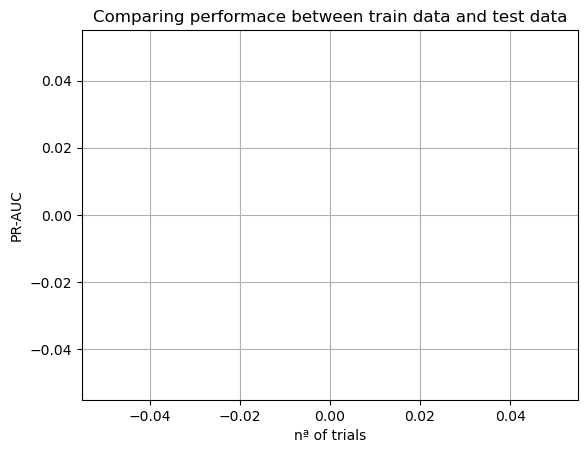

In [17]:
y_1 = [v[0] for v in value_comp]
y_2 = [v[1] for v in value_comp]

plt.plot(y_1, label="train data", marker="o")
plt.plot(y_2, label="test data", marker="s")

plt.xlabel("nª of trials")
plt.ylabel("PR-AUC")
plt.title("Comparing performace between train data and test data")
plt.grid(True)
plt.show()

In [ ]:
trials = list(range(len(value_comp)))

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=trials,
        y = y_2,
        mode="lines+markers",
        name="Trial Data"
    )
)

fig.add_trace(
    go.Scatter(
        x=trials,
        y=y_2,
        mode="lines+markers",
        name="Test Data",
        customdata=dfresults.T.to_numpy(),
        hovertemplate=(
            "<b>Trial %{x}</b><br>"
            + "PR-AUC: %{y:.4f}<br><br>"
            + "<br>".join(
                [
                    f"{metric}: %{{customdata[{i}]}}"
                    for i, metric in enumerate(dfresults.index)
                ]
            )
            + "<extra></extra>" 
        ),
    )
)

fig.update_layout(
    title="Comparing performance between train data and test data",
    xaxis_title="nº of trials",
    yaxis_title="PR-AUC",
    hovermode="closest",
)

fig.show(renderer="browser")